### Libraries and Imports


In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.spatial import KDTree
from scipy.interpolate import RegularGridInterpolator
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from datetime import date
%matplotlib inline
from trajectory_video import make_trajectory_video
from trajectory_video2 import make_trajectory_video1
from training_progress_video import make_training_progress_video
import re
import glob
import matplotlib as mpl
import matplotlib.animation as animation
import imageio_ffmpeg
mpl.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()

### PDE and FD reference Parameters and RL action space


In [22]:
# PDE 
alpha = 0.05

#   FD reference grid   
nx    = 50

T     = 1
x_fd  = np.linspace(0.0, 1.0, nx)
dx    = x_fd[1] - x_fd[0]

dt_cfl = 0.45 * dx**2 / alpha
nt     = max(int(np.ceil(T / dt_cfl)) + 1, 10)
t_fd   = np.linspace(0.0, T, nt)
dt     = t_fd[1] - t_fd[0]

#  True solution; Analytical diffusion solution

def u_true(x, t):
    return np.sin(np.pi * x) * np.exp(-alpha * np.pi**2 * t)

 

### FD For diffusion

In [23]:
def build_fd_reference():
    u = np.zeros((nx, nt))
    u[:, 0] = u_true(x_fd, 0.0)

    r_diff = alpha * dt / dx**2

    for it in range(nt - 1):
        un = u[:, it]
        u[1:-1, it+1] = (un[1:-1]
                         + r_diff * (un[2:] - 2*un[1:-1] + un[:-2]))
        u[0,   it+1] = 0.0
        u[-1,  it+1] = 0.0

    interp = RegularGridInterpolator(
        (x_fd, t_fd), u, method='linear',
            bounds_error=False, fill_value=None
    )
    return u, interp

### __ init __

In [24]:
class VisitedSet:

    def __init__(self, rebuild_every=200):
        self._pts           = []
        self._norm          = []
        self._tree          = None
        self._dirty         = 0
        self._rebuild_every = rebuild_every
        self._idx_set       = set()               
        self.rejected_history = []  # (x, t) per rejected move
    def add(self, x, t, u):
        self._idx_set.add((round(x / dx), round(t / dt)))  
        self._pts.append((x, t, u))
        self._norm.append((x / dx, t / dt))
        self._dirty += 1
        if self._dirty >= self._rebuild_every:
            self._rebuild()
    def _rebuild(self):
        self._tree  = KDTree(np.array(self._norm))
        self._dirty = 0
    def contains(self, x, t):                    
        return (round(x / dx), round(t / dt)) in self._idx_set
    def find_neighbours(self, x_star, t_star, n, eps_norm=0.5):
            if len(self._pts) < n:
                return None
            pts_arr  = np.asarray(self._pts)
            norm_arr = np.asarray(self._norm)
            mask = pts_arr[:, 1] < t_star
            if mask.sum() < n:
                return None
            norm_c = norm_arr[mask]
            pts_c  = pts_arr[mask]
            target = np.array([x_star / dx, t_star / dt])
            d2     = np.sum((norm_c - target) ** 2, axis=1)

            # ── Exclude points essentially coincident with z* ────────────────
            # In a reconstruction stencil, a neighbour sitting on the query
            # point leaks the answer. eps_norm=0.5 ≈ half a grid cell, i.e. the
            # reach tolerance (eps_x=0.5dx, eps_t=0.5dt) in normalized units.
            keep = d2 > eps_norm**2
            if keep.sum() < n:
                return None
            norm_c = norm_c[keep]
            pts_c  = pts_c[keep]
            d2     = d2[keep]

            idx = np.argpartition(d2, n - 1)[:n]
            idx = idx[np.argsort(d2[idx])]

            return [tuple(row) for row in pts_c[idx]]

    def __len__(self):
            return len(self._pts)

### GFDM Solver


In [25]:
def solve_weights(dx_i, dt_i):
    h = max(np.max(np.abs(dx_i)), 1e-12)

    A = np.array([
        np.ones(len(dx_i)),
        dx_i / h,
        (0.5 * dx_i**2 + alpha * dt_i) / h**2,
    ])
    b = np.array([1.0, 0.0, 0.0])

    cond = np.linalg.cond(A)
    if cond > 1e4:
        return None, 'cond'

    w = np.linalg.lstsq(A, b, rcond=None)[0]

    #if np.max(np.abs(w)) > 3.0 / len(dx_i):
    #    return None, 'weights'
    #if np.min(w) < -1.0:
    #    return None, 'weights'

    return w, 'ok'

### PDEEnvironment

In [26]:
class PDEEnvironment(gym.Env):
    # only allow up
    #ACTIONS = {0 :(0,1), 1: (0,2) }  
    # can go diagonally up-left, up, or up-right
    ACTIONS = {0: (-1, 1),   # up-left
               1: ( 0, 1),   # straight forward
               2: ( 1, 1),   # up-right
               3: (1,0),
               4: (-1,0)
               }
    def __init__(self, t_star_schedule=None, t_star_steps=2, N_particles=27,
                 lam=0.001, beta=100.0, K_max=500, c_shape=0.0,
                 x_star_idx=None, x_star_schedule=None):
        super().__init__()

        #   PDE constants  
        self.alpha = alpha

        #G6id variables  
        self.nx   = nx
        self.nt   = nt
        self.x_fd = x_fd
        self.t_fd = t_fd
        self.dx   = dx
        self.dt   = dt
        self.T    = T
 
        # ── t* schedule: dict {t_star_steps: K_max}. None → fixed single t*. ─────
        # When set, t* (and its matched K_max) is resampled every reset().
        self.t_star_schedule = dict(t_star_schedule) if t_star_schedule else None

        # ── Target point (z*) ───────────────────────────────────────────────────
        # ── Target point (z*) ───────────────────────────────────────────────────
        # x* stored as a grid index so it snaps to x_fd; None → domain centre.
        self.x_star_schedule = list(x_star_schedule) if x_star_schedule else None
        self._x_star_idx_default = self.nx // 2 if x_star_idx is None else int(x_star_idx)
        self.x_star_idx = self._x_star_idx_default
        self.x_star = self.x_fd[self.x_star_idx]
        self.t_star_steps = t_star_steps          # provisional; reset() may override
        self.t_star = t_star_steps * dt

        # ── RL parameters ───────────────────────────────────────────────────────
        self.K_max  = K_max
        self.lam    = lam
        self.beta = beta

        # ── GFDM neighbours ─────────────────────────────────────────────────────
        self.n_neighbours = 5

        # ── Termination tolerance ───────────────────────────────────────────────
        self.eps_x = 0.5 * dx
        self.eps_t = 0.5 * dt

        # ── Walker initial positions  ────────────────────────────────────────────
        self.N = N_particles

        mid    = self.nx // 2
        margin = 2
        half_n = self.N // 2
        step   = (mid - margin) / half_n if half_n > 0 else 0

        offsets= [0]
        k = 1
        while len(offsets) < self.N:
            offsets.append(k * step)
            if len(offsets) < self.N:
                offsets.append(-k * step)
            k += 1

        init_idx = np.clip(np.round(np.array(offsets[:self.N]) + mid).astype(int), margin, self.nx - 1 - margin)
        self.walker_init_x = self.x_fd[init_idx]

        # ── FD reference built once ──────────────────────────────────────────────
        _, self.fd_interp = build_fd_reference()

        # ── Episode state (reset() fills these) ──────────────────────────────────
        self.visited     = None
        self.walker_x    = None
        self.walker_t    = None
        self.walker_u    = None
        self.step_count  = 0
        self.stencil_log = {}

        # ── Gym spaces ───────────────────────────────────────────────────────────
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(2 * self.N+2,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(self.N * len(self.ACTIONS))



    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # ── Resample t* (and matched K_max) per episode if a schedule is set ─────
        if self.t_star_schedule is not None:
            choices = list(self.t_star_schedule.keys())
            self.t_star_steps = int(self.np_random.choice(choices))
            self.t_star = self.t_star_steps * self.dt
            self.K_max  = self.t_star_schedule[self.t_star_steps]
        # ── Resample x* per episode if a schedule is set ─────────────────────────
        if self.x_star_schedule is not None:
            self.x_star_idx = int(self.np_random.choice(self.x_star_schedule))
        else:
            self.x_star_idx = self._x_star_idx_default
        self.x_star = self.x_fd[self.x_star_idx]

        self.visited     = VisitedSet()
        self.stencil_log = {}
        # ── Seed with IC ─────────────────────────────────────────────────────────
        for ix in range(self.nx):
            x = self.x_fd[ix]
            self.visited.add(x, 0.0, u_true(x, 0.0))
        # ── Seed with BCs ────────────────────────────────────────────────────────
        for it in range(1, self.nt):
            self.visited.add(0.0, self.t_fd[it], 0.0)
            self.visited.add(1.0, self.t_fd[it], 0.0)
        # ── Place walkers at t=0 (always centered spread from __init__) ──────────
        self.walker_x = np.array(self.walker_init_x, dtype=float)
        self.walker_t = np.zeros(self.N)
        self.walker_u = np.array([u_true(x, 0.0) for x in self.walker_x])
        self.step_count = 0
        self.rejected_history = []
        self.gfdm_rejected_set = set()
        return self._build_obs(), {}


    def _build_obs(self):
        dx_rel = (self.walker_x - self.x_star) / self.dx
        dt_rel = (self.walker_t - self.t_star) / self.dt
        t_star_norm = self.t_star / self.dt   # = t_star_steps, horizon length in step units
        x_star_norm = self.x_star / self.dx   # = x_star_idx, grid index of x_star
        return np.array([
            *dx_rel,
            *dt_rel,
            t_star_norm,
            x_star_norm,
        ], dtype=np.float32)

    def _gfdm_solve(self, x_star, t_star):
        nb = self.visited.find_neighbours(x_star, t_star, self.n_neighbours)
        if nb is None:
            return None, False, None, 'no_nb'

        nb   = np.array(nb)
        dx_i = nb[:, 0] - x_star
        dt_i = nb[:, 1] - t_star

        #if not (np.min(dx_i) < 0 < np.max(dx_i)):
        #    return None, False, None, 'geometry'

        w, reason = solve_weights(dx_i, dt_i)
        if w is None:
            return None, False, None, reason

        u_hat = float(w @ nb[:, 2])
        #if abs(u_hat) > 1.1:
        #    return None, False, None, 'bounds_u'
        return u_hat, True, nb[:, :2], 'ok'
    def step(self, action):

            self.step_count += 1
            done   = False
            reward = 0.0

            i              = int(action) // len(self.ACTIONS)
            j              = int(action) % len(self.ACTIONS)
            dx_idx, dt_idx = self.ACTIONS[j]
            dx_move = dx_idx * self.dx
            dt_move = dt_idx * self.dt

            info = {'walker': i, 'accepted': False, 'rejected': None, 'reached': False}

            x_new = self.walker_x[i] + dx_move
            t_new = self.walker_t[i] + dt_move

            if not (0.0 <= x_new <= 1.0 and 0.0 < t_new <= self.T):
                info['rejected'] = 'bounds'

            elif self.visited.contains(x_new, t_new):
                info['rejected'] = 'collision'

            else:
                u_hat, success, nb_coords, reason = self._gfdm_solve(x_new, t_new)
                if not success:
                    info['rejected'] = reason
                    self.gfdm_rejected_set.add(int(action))
                    
                else:
                    self.gfdm_rejected_set.clear()
                    self.visited.add(x_new, t_new, u_hat)
                    self.walker_x[i] = x_new
                    self.walker_t[i] = t_new
                    self.walker_u[i] = u_hat
                    self.stencil_log[(round(x_new, 8), round(t_new, 8))] = nb_coords
                    info['accepted'] = True

                    if (abs(x_new - self.x_star) < self.eps_x and
                        abs(t_new - self.t_star) < self.eps_t):
                        done = True
                        info['reached'] = True

            # ── track rejected positions ──────────────────────────────────────────
            if not info['accepted']:
                self.rejected_history.append((x_new, t_new, info['rejected']))
            # ─────────────────────────────────────────────────────────────────────
            worst_case_timeout = -100.0

            if done:
                u_pred, _, _, _ = self._gfdm_solve(self.x_star, self.t_star)
                u_ref           = u_true(self.x_star, self.t_star)

                if u_pred is None:
                    reward               = worst_case_timeout
                    info['error']        = None
                    info['solve_failed'] = True
                else:
                    reward = -(self.beta * abs(u_pred - u_ref) + self.lam * self.step_count)
                    info['u_pred'] = u_pred
                    info['u_ref']  = u_ref
                    info['error']  = abs(u_pred - u_ref)
                    info['k_term'] = self.step_count

            elif self.step_count >= self.K_max:
                done   = True
                reward = worst_case_timeout
                info['timeout'] = True

            return self._build_obs(), reward, done, False, info
    def action_masks(self) -> np.ndarray:
        mask = np.ones(self.N * len(self.ACTIONS), dtype=bool)
        for i in range(self.N):
            for j in range(len(self.ACTIONS)):
                dx_idx, dt_idx = self.ACTIONS[j]
                x_new = self.walker_x[i] + dx_idx * self.dx
                t_new = self.walker_t[i] + dt_idx * self.dt
                if not (0.0 <= x_new <= 1.0 and
                        0.0 < t_new <= 1.5 * self.t_star and
                        not self.visited.contains(x_new, t_new)):
                    mask[i * len(self.ACTIONS) + j] = False
        for a in self.gfdm_rejected_set:
            mask[a] = False
        if not mask.any():
            mask[:] = True
        return mask

### Sanity Check: Random Policy Baseline

Steps:          500
Reward:         -100.000000
Reached:        False
Timeout:        True
Total accepted: 311
Total rejected: 189
Rejection reasons:
  collision : 163
  bounds    : 26

Accepted moves per walker:
  Walker 0: 24
  Walker 1: 5
  Walker 2: 7
  Walker 3: 16
  Walker 4: 15
  Walker 5: 3
  Walker 6: 8
  Walker 7: 13
  Walker 8: 19
  Walker 9: 5
  Walker 10: 18
  Walker 11: 2
  Walker 12: 21
  Walker 13: 9
  Walker 14: 15
  Walker 15: 4
  Walker 16: 11
  Walker 17: 16
  Walker 18: 2
  Walker 19: 6
  Walker 20: 9
  Walker 21: 20
  Walker 22: 19
  Walker 23: 20
  Walker 24: 6
  Walker 25: 4
  Walker 26: 14


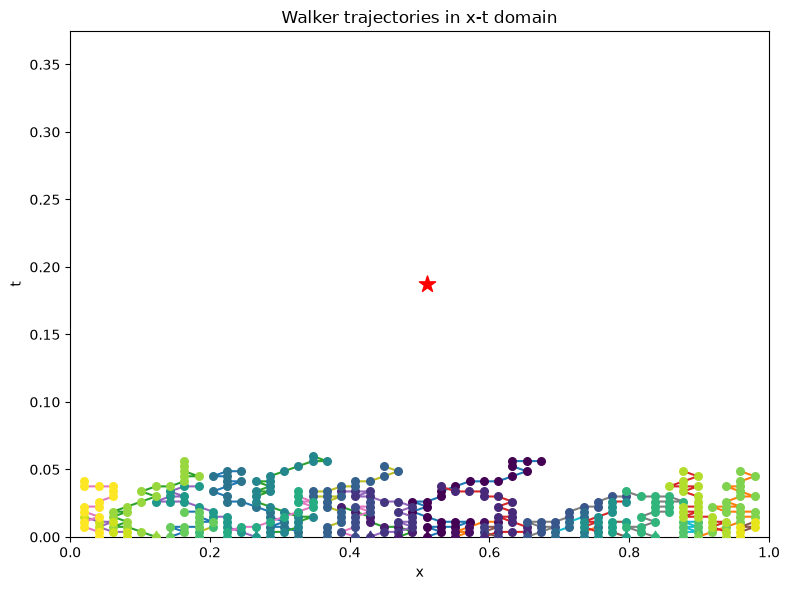

In [27]:
t_star_steps = 50  # ← change this to test different targets\
x_star_idx   = 25   # ← change this to test different x* (grid index, nx//2 = centre)
K_max=100
env      = PDEEnvironment(t_star_steps=t_star_steps)
state, _ = env.reset()

trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}

done           = False
total_accepted = 0
total_rejected = {}

while not done:
    action = env.action_space.sample()
    state, reward, done, _, info = env.step(action)



    total_accepted += int(info['accepted'])
    if info['rejected']:
        reason = info['rejected']
        total_rejected[reason] = total_rejected.get(reason, 0) + 1

    if info['accepted']:
        i = info['walker']
        trajectories[i].append((env.walker_x[i], env.walker_t[i]))

visited_log = [(x, t) for (x, t, _) in env.visited._pts
               if t > 0.0 and 0.0 < x < 1.0]

print(f"Steps:          {env.step_count}")
print(f"Reward:         {reward:.6f}")
print(f"Reached:        {info.get('reached', False)}")
print(f"Timeout:        {info.get('timeout', False)}")
print(f"Total accepted: {total_accepted}")
print(f"Total rejected: {sum(total_rejected.values())}")
print("Rejection reasons:")

for reason, count in sorted(total_rejected.items(), key=lambda kv: -kv[1]):
    print(f"  {reason:10s}: {count}")
# walker distribution check — tells you if one walker is dominating
walker_counts = {}
for i, traj in trajectories.items():
    walker_counts[i] = len(traj) - 1  # subtract starting position
print("\nAccepted moves per walker:")
for i, count in sorted(walker_counts.items()):
    print(f"  Walker {i:d}: {count}")

fig, ax = plt.subplots(figsize=(8, 6))

vx = [p[0] for p in visited_log]
vt = [p[1] for p in visited_log]
ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

colors = plt.cm.viridis(np.linspace(0, 1, env.N))
for i, traj in trajectories.items():
    xs = [p[0] for p in traj]
    ts = [p[1] for p in traj]
    ax.plot(xs, ts, '-', linewidth=1.5, zorder=2)
    ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
    ax.scatter(xs[0], ts[0], s=80, color=colors[i],
               marker='^', zorder=4, label=f'Walker {i}')

ax.scatter(env.x_star, env.t_star, s=150, color='red',
           marker='*', zorder=5, label='z*')

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Walker trajectories in x-t domain')
ax.set_xlim(0, 1)
ax.set_ylim(0, env.t_star * 2)
plt.tight_layout()
plt.show()

## Plot Trajactories


In [28]:
def plot_trajectories(model, t_star_steps, N_particles, lam, beta, K_max, c_shape,
                      save=True, timestep=None, img_dir=".", label=None, x_star_idx=None):
    env = PDEEnvironment(t_star_steps=t_star_steps, N_particles=N_particles,
                         lam=lam, beta=beta, K_max=K_max, c_shape=c_shape,
                         x_star_idx=x_star_idx)
    obs, _ = env.reset()
    trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True, action_masks=env.action_masks())
        obs, reward, done, _, info = env.step(action)
        if info['accepted']:
            i = info['walker']
            trajectories[i].append((env.walker_x[i], env.walker_t[i]))

    visited_log = [(x, t) for (x, t, _) in env.visited._pts]
    fig, ax = plt.subplots(figsize=(8, 6))

    vx = [p[0] for p in visited_log]
    vt = [p[1] for p in visited_log]
    ax.scatter(vx, vt, s=4, color='lightgray', zorder=1)

    # ── Rejected positions ───────────────────────────────────────────────────
    rej_colors = {
        'bounds':    'blue',
        'collision': 'orange',
        'cond':      'purple',
        'weights':   'brown',
        'geometry':  'red',
        None:        'gray',
    }
    if env.rejected_history:
        from collections import defaultdict
        by_reason = defaultdict(list)
        for (rx, rt, reason) in env.rejected_history:
            by_reason[reason].append((rx, rt))
        for reason, pts in by_reason.items():
            ax.scatter([p[0] for p in pts], [p[1] for p in pts],
                       s=6, alpha=0.08, linewidths=0, zorder=1,
                       color=rej_colors.get(reason, 'gray'),
                       label=f'rej:{reason} ({len(pts)})')
    # ─────────────────────────────────────────────────────────────────────────

    colors = plt.cm.viridis(np.linspace(0, 1, env.N))
    for i, traj in trajectories.items():
        xs = [p[0] for p in traj]
        ts = [p[1] for p in traj]
        ax.plot(xs, ts, '-', linewidth=1.5, color=colors[i], zorder=2)
        ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
        ax.scatter(xs[0], ts[0], s=80, color=colors[i], marker='^', zorder=4)

    reached = info.get('reached', False)
    outcome = 'reached' if reached else 'timeout'

    # ── Stencil at z* ────────────────────────────────────────────────────────
    if reached:
        _, success, nb_coords, _ = env._gfdm_solve(env.x_star, env.t_star)
        if success and nb_coords is not None:
            for (nx_, nt_) in nb_coords:
                ax.plot([env.x_star, nx_], [env.t_star, nt_],
                        '--', color='red', linewidth=0.8,
                        alpha=0.7, zorder=5)
            ax.scatter(nb_coords[:, 0], nb_coords[:, 1],
                       s=40, color='red', zorder=6, alpha=0.7)

    ax.scatter(env.x_star, env.t_star, s=150, color='red', marker='*', zorder=7)
    ax.set_xlabel('x')
    ax.set_ylabel('t')

    title = f't_star={t_star_steps}·dt  |  {outcome}'
    if timestep is not None:
        title += f'  |  step {timestep:,}'
    if reached and info.get('error') is not None:
        title += f'  |  err={info["error"]:.2e}  |  k={info["k_term"]}'
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, env.t_star * 2)

    if env.rejected_history:
        ax.legend(fontsize=6, loc='upper left', markerscale=2)

    plt.tight_layout()

    if save:
        if label is not None:
            fname = f'traj_t{t_star_steps}dt_{label}_{outcome}.png'
        elif timestep is not None:
            fname = f'traj_t{t_star_steps}dt_{timestep//1000:05d}k_{outcome}.png'
        else:
            fname = f'traj_t{t_star_steps}dt_{outcome}.png'
        fig.savefig(os.path.join(img_dir, fname), dpi=120)
        plt.close(fig)
    else:
        plt.show()

In [29]:
class ReachedRateCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.buf       = []
        self.kterm_buf = []
        self.err_buf   = []

    def _on_step(self) -> bool:
        for info in self.locals['infos']:
            if info.get('reached'):
                self.buf.append(1)
                k = info.get('k_term')
                e = info.get('error')
                if k is not None and e is not None:
                    self.kterm_buf.append(k)
                    self.err_buf.append(e)
            elif info.get('timeout'):
                self.buf.append(0)
        if self.buf:
            self.logger.record('rollout/reached_rate',
                               sum(self.buf[-100:]) / len(self.buf[-100:]))
        if self.kterm_buf:
            self.logger.record('rollout/mean_kterm_on_reach',
                               np.mean(self.kterm_buf[-100:]))
            self.logger.record('rollout/mean_error_on_reach',
                               np.mean(self.err_buf[-100:]))
        return True

In [30]:
class PlotCallback(BaseCallback):
    def __init__(self, t_star_steps, N_particles, lam, beta, K_max, c_shape, x_star_idx, plot_freq=50_000, img_dir=".", verbose=0):
        super().__init__(verbose)
        self.t_star_steps = t_star_steps
        self.N_particles  = N_particles
        self.lam          = lam
        self.beta         = beta
        self.K_max        = K_max
        self.c_shape      = c_shape
        self.x_star_idx   = x_star_idx
        self.plot_freq    = plot_freq
        self.last_plot_at = 0
        self.img_dir      = img_dir

    def _on_step(self) -> bool:
        if self.num_timesteps - self.last_plot_at >= self.plot_freq:
            self.last_plot_at = self.num_timesteps
            plot_trajectories(self.model,
                              t_star_steps=self.t_star_steps,
                              N_particles=self.N_particles,
                              lam=self.lam, beta=self.beta,
                              K_max=self.K_max, c_shape=self.c_shape,
                              x_star_idx=self.x_star_idx,
                              save=True, timestep=self.num_timesteps,
                              img_dir=self.img_dir)
        return True

def make_env(t_star_schedule, N_particles, lam, beta, K_max, c_shape, x_star_idx=None):
    def _init():
        env = PDEEnvironment(t_star_schedule=t_star_schedule, N_particles=N_particles,
                             lam=lam, beta=beta, K_max=K_max, c_shape=c_shape,
                             x_star_idx=x_star_idx)
        env = ActionMasker(env, lambda e: e.action_masks())
        return Monitor(env)
    return _init

In [31]:
# ── Run configuration ────────────────────────────────────────────────────────
N_particles     = 1
t_star_schedule = {30: 400}   # {t_star_steps: K_max}
x_star_idx      = 25          # grid index; nx//2 = 50 = centre
c_shape         = 0.0
seeds           = [3]
lam             = 0.01
beta            = 1000
n_envs          = 15
n_steps         = 2048 // n_envs
total_timesteps = 1_000_000

# representative t* / x* used ONLY for periodic plots/videos
plot_tstar      = 30
plot_x_star_idx = x_star_idx
plot_K_max      = t_star_schedule[plot_tstar]

# ── Run directory ────────────────────────────────────────────────────────────
day        = date.today().day
stages_str = "-".join(str(s) for s in t_star_schedule.keys())
run_name   = f"t{stages_str}_lam{lam}_beta{beta}_N{N_particles}_x{x_star_idx}"
run_dir    = os.path.join(f"runs{day}", run_name)

print(f"Run: {run_dir}")
print(f"Training jointly on t*={list(t_star_schedule.keys())}  "
      f"(periodic plots at t*={plot_tstar}, x*_idx={plot_x_star_idx})")

for seed in seeds:

    seed_dir  = os.path.join(run_dir, f"seed{seed}")
    img_dir   = os.path.join(seed_dir, "images")
    ckpt_dir  = os.path.join(seed_dir, "checkpoints")

    os.makedirs(img_dir,  exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)

    print(f"\n{'#'*50}\nSEED {seed}\n{'#'*50}")

    # every subprocess gets the SAME schedule and resamples t* per episode in reset()
    vec_env = SubprocVecEnv([
        make_env(t_star_schedule, N_particles, lam, beta,
                 K_max=None, c_shape=c_shape, x_star_idx=x_star_idx)
        for _ in range(n_envs)
    ])

    model = MaskablePPO(
        "MlpPolicy",
        vec_env,
        verbose=1,
        seed=seed,
        tensorboard_log=os.path.join(seed_dir, "logs"),
        learning_rate=2e-4,
        clip_range=0.1,
        n_steps=n_steps,
        batch_size=60,
        gamma=1.0,
        ent_coef=0.01,
        device="cpu",
    )

    print(f"\n{'='*50}")
    print(f"Joint training over t* schedule: {t_star_schedule}")
    print(f"budget: {total_timesteps//1000}k steps")
    print(f"{'='*50}")

    model.learn(
        total_timesteps=total_timesteps,
        reset_num_timesteps=False,
        tb_log_name=f"seed{seed}",
        log_interval=10,
        callback=[
            ReachedRateCallback(),
            PlotCallback(plot_tstar, N_particles, lam, beta, plot_K_max, c_shape,
                         plot_freq=100_000, img_dir=img_dir, x_star_idx=plot_x_star_idx),
            CheckpointCallback(
                save_freq=100_000,
                save_path=os.path.join(ckpt_dir, "sched"),
                name_prefix="sched"
            ),
        ],
    )

    model.save(os.path.join(ckpt_dir, "sched_final"))

    # final plots at the representative t* / x*
    plot_trajectories(model,
                      t_star_steps=plot_tstar,
                      N_particles=N_particles,
                      lam=lam, beta=beta,
                      K_max=plot_K_max, c_shape=c_shape,
                      x_star_idx=plot_x_star_idx,
                      save=True, timestep=None, img_dir=img_dir, label="final")
    # make_trajectory_video2(...)  # left commented as in your version

Run: runs20\t30_lam0.01_beta1000_N1_x25
Training jointly on t*=[30]  (periodic plots at t*=30, x*_idx=25)

##################################################
SEED 3
##################################################
Using cpu device

Joint training over t* schedule: {30: 400}
budget: 1000k steps
Logging to runs20\t30_lam0.01_beta1000_N1_x25\seed3\logs\seed3_0
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 385           |
|    ep_rew_mean          | -95.8         |
|    mean_error_on_reach  | 0.00114       |
|    mean_kterm_on_reach  | 42.5          |
|    reached_rate         | 0.0426        |
| time/                   |               |
|    fps                  | 2138          |
|    iterations           | 10            |
|    time_elapsed         | 9             |
|    total_timesteps      | 20400         |
| train/                  |               |
|    approx_kl            | 0.00010006691 |
|    clip_fraction    

success: True reason: ok
n returned: 5
[[0.51020408 0.10861423]
 [0.51020408 0.10486891]
 [0.51020408 0.1011236 ]
 [0.53061224 0.09737828]
 [0.53061224 0.09363296]]


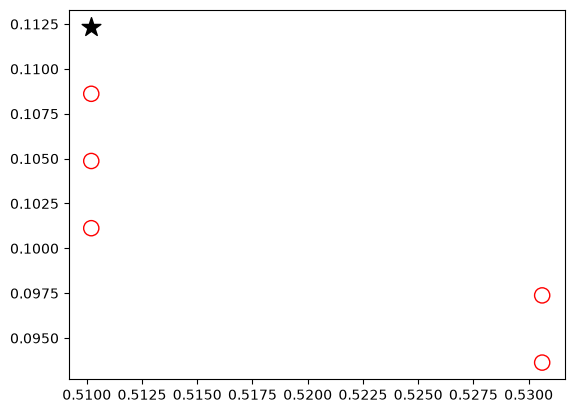

In [32]:
env = PDEEnvironment(t_star_steps=30, N_particles=1, x_star_idx=25)   # match the figure's config
obs, _ = env.reset()
done = False
while not done:
    mask = env.action_masks()
    action, _ = model.predict(obs, action_masks=mask, deterministic=True)
    obs, r, term, trunc, info = env.step(int(action))
    done = term or trunc

_, success, nb_coords, reason = env._gfdm_solve(env.x_star, env.t_star)
print("success:", success, "reason:", reason)
print("n returned:", None if nb_coords is None else len(nb_coords))
print(nb_coords)
import matplotlib.pyplot as plt
plt.scatter(nb_coords[:,0], nb_coords[:,1], s=120,
            facecolors='none', edgecolors='red')
plt.scatter(env.x_star, env.t_star, marker='*', s=200, color='k')
plt.show()

Rollout done: timeout, 489 accepted points, 500 total steps.


KeyboardInterrupt: 

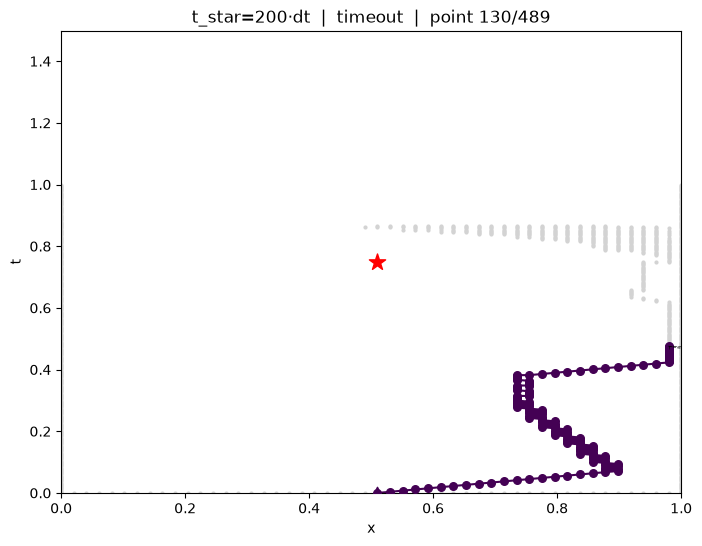

In [33]:
from trajectory_video import make_trajectory_video

make_trajectory_video(
    model,
    PDEEnvironment,
    200,
    N_particles,
    img_dir=img_dir,)

## Test the policy on different t*


── test t*=40·dt  x*_idx=25  (K_max=400)  [OUT-of-schedule (extrapolation)] ──
  steps=45  reward=-2.001586
  reached=True  timeout=False  error=0.001551586120049464
  accepted=42  rejected=3
    cond      : 3
  dt_rel visited: min=-39.0  max=0.0  (training floor for this t* is -40)


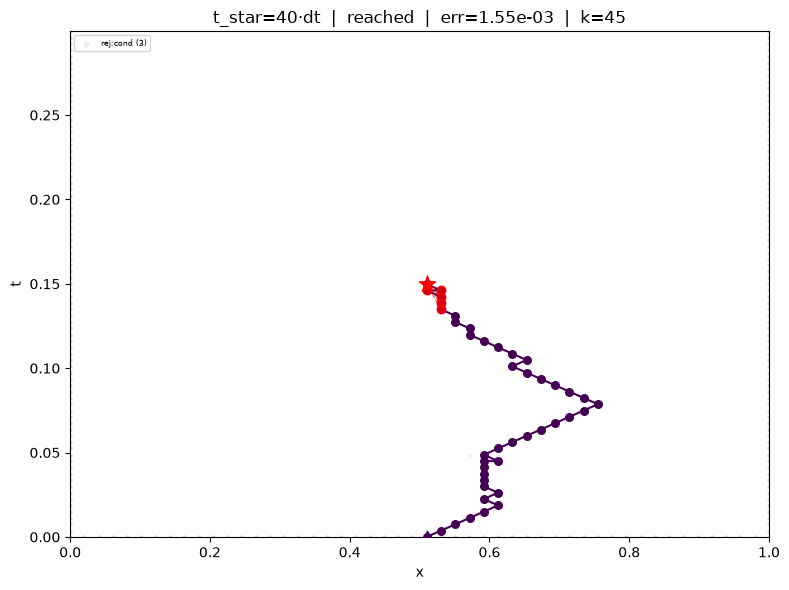

In [51]:
# ── Pick any t* and see its plot + diagnostics ───────────────────────────────
CHOOSE_TSTAR = 40          # ← the t* you want to test
CHOOSE_XIDX  =   x_star_idx   # ← x* grid index; must match how you trained

def test_at_tstar(model, t_star_steps_test, N_particles, lam, beta, K_max_test,
                  c_shape=0.0, x_star_idx=None, deterministic=True):
    """Evaluate `model` at a chosen t*. Fixed-t* env (schedule=None) so the
    horizon is exactly what you asked for. Passes all hyperparameters explicitly."""
    env = PDEEnvironment(t_star_schedule=None, t_star_steps=t_star_steps_test,
                         N_particles=N_particles, lam=lam, beta=beta,
                         K_max=K_max_test, c_shape=c_shape, x_star_idx=x_star_idx)
    obs, _ = env.reset()

    total_accepted = 0
    total_rejected = {}
    dt_rel_hist = []
    done = False
    while not done:
        masks = env.action_masks()
        action, _ = model.predict(obs, action_masks=masks, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        dt_rel_hist.append((env.walker_t.copy() - env.t_star) / env.dt)
        total_accepted += int(info['accepted'])
        if info['rejected']:
            r = info['rejected']; total_rejected[r] = total_rejected.get(r, 0) + 1

    in_sched = t_star_steps_test in t_star_schedule
    tag = "IN-schedule" if in_sched else "OUT-of-schedule (extrapolation)"
    print(f"── test t*={t_star_steps_test}·dt  x*_idx={x_star_idx}  "
          f"(K_max={K_max_test})  [{tag}] ──")
    print(f"  steps={env.step_count}  reward={reward:.6f}")
    print(f"  reached={info.get('reached', False)}  timeout={info.get('timeout', False)}"
          f"  error={info.get('error')}")
    print(f"  accepted={total_accepted}  rejected={sum(total_rejected.values())}")
    for r, c in sorted(total_rejected.items(), key=lambda kv: -kv[1]):
        print(f"    {r:10s}: {c}")
    if dt_rel_hist:
        arr = np.concatenate(dt_rel_hist)
        print(f"  dt_rel visited: min={arr.min():.1f}  max={arr.max():.1f}  "
              f"(training floor for this t* is -{t_star_steps_test})")

    # reuse existing plotter, don't save → renders inline
    # (requires plot_trajectories to plt.show() when save=False)
    plot_trajectories(model, t_star_steps_test, N_particles,
                      lam, beta, K_max_test, c_shape,
                      save=False, x_star_idx=x_star_idx)
    return info

info = test_at_tstar(model, t_star_steps_test=CHOOSE_TSTAR,
                     N_particles=N_particles, lam=lam, beta=beta,
                     K_max_test=t_star_schedule.get(CHOOSE_TSTAR, 400),
                     c_shape=c_shape, x_star_idx=CHOOSE_XIDX)

In [ ]:
import inspect
print(inspect.getsource(PDEEnvironment.reset))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # ── Resample t* (and matched K_max) per episode if a schedule is set ─────
        if self.t_star_schedule is not None:
            choices = list(self.t_star_schedule.keys())
            self.t_star_steps = int(self.np_random.choice(choices))
            self.t_star = self.t_star_steps * self.dt
            self.K_max  = self.t_star_schedule[self.t_star_steps]

        # ── Resample x* per episode if a schedule is set ─────────────────────────
        if self.x_star_schedule is not None:
            self.x_star_idx = int(self.np_random.choice(self.x_star_schedule))
        else:
            self.x_star_idx = self._x_star_idx_default
        self.x_star = self.x_fd[self.x_star_idx]

        # ── Re-center walker initial spread around current x* ────────────────────
        margin = 2
        half_n = self.N // 2
        span   = min(self.x_star_idx - margin, self.nx - 1 - margin - self.x_star_idx)
 